In [1]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, default_data_collator
from torch.utils.data import DataLoader
from datasets import load_dataset
from chop import MaseGraph
import matplotlib.pyplot as plt

/home/dt822/adls/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/dt822/adls/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    props = torch.cuda.get_device_properties(0)
    print("Using CUDA device:", props.name)
else:
    DEVICE = torch.device("cpu")
    print("CUDA not available — using CPU")

BERT_CKPT = "bert-base-glue-mnli-baseline"
ROBERTA_CKPT = "roberta-base-glue-mnli-baseline"
NUM_LABELS = 3

# === Data ===
raw_mnli = load_dataset("glue", "mnli")
raw_mnli = raw_mnli.filter(lambda x: x["label"] >= 0)
raw_mnli["test"] = raw_mnli["validation_matched"]

def get_dataloader(tokenizer_ckpt, split_size=0.5):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_ckpt)
    ds = raw_mnli.map(
        lambda x: tokenizer(x["premise"], x["hypothesis"], truncation=True, padding="max_length", max_length=128),
        batched=True,
    )
    cols_to_remove = [c for c in ds["test"].column_names if c not in ["input_ids", "attention_mask", "label"]]
    ds_test = ds["test"].remove_columns(cols_to_remove).rename_column("label", "labels")
    ds_split = ds_test.train_test_split(0.5, 0.5, seed=42)
    dataloader = DataLoader(ds_split["test"], batch_size=32, collate_fn=default_data_collator, shuffle=True)
    return dataloader

print("Preparing BERT data...")
bert_dataloader = get_dataloader("bert-base-uncased")

print("Preparing RoBERTa data...")
roberta_dataloader = get_dataloader("roberta-base")

Using CUDA device: NVIDIA RTX A6000
Preparing BERT data...
Preparing RoBERTa data...


In [3]:
@torch.no_grad()
def eval_accuracy(model, dataloader, device="cuda"):
    model.eval()
    correct, total = 0, 0
    for batch in tqdm(dataloader, desc="Eval Accuracy"):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        logits = out["logits"] if isinstance(out, dict) else out.logits
        correct += (logits.argmax(dim=-1) == batch["labels"]).sum().item()
        total += batch["labels"].size(0)
    acc = correct / total
    print(f"Accuracy: {acc * 100:.2f}% ({correct}/{total})")
    return acc

@torch.no_grad()
def eval_speed(model, dataloader, device="cuda", num_batches=100, warmup=10):
    model.eval()
    batches = list(dataloader)[:warmup + num_batches]
    # warmup
    for b in batches[:warmup]:
        model(**{k: v.to(device) for k, v in b.items()})
    if device == "cuda" or (hasattr(device, 'type') and device.type == "cuda"):
        torch.cuda.synchronize()

    # timed
    times, samples = [], 0
    for b in batches[warmup:]:
        if device == "cuda" or (hasattr(device, 'type') and device.type == "cuda"):
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        model(**{k: v.to(device) for k, v in b.items()})
        if device == "cuda" or (hasattr(device, 'type') and device.type == "cuda"):
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
        samples += b["input_ids"].size(0)
    avg_per_batch_ms = np.mean(times) * 1000
    avg_per_sample_ms = (sum(times) / samples) * 1000
    total = sum(times)
    # print(f"{samples} samples in {total:.4f}s")
    # print(f"Throughput:      {samples / total:.1f} samples/sec")
    # print(f"Avg batch:       {np.mean(times) * 1000:.2f} ms")
    return [avg_per_batch_ms, avg_per_sample_ms]

In [4]:
class EarlyExitMixin:
    """
    A mixin that provides universal early exit tracking, confidence 
    evaluation, and classifier routing.
    """
    def init_early_exit(self, original_model, threshold):
        self.threshold = threshold
        self.num_labels = original_model.config.num_labels
        self.pooler = None # Will be overridden by subclass if applicable
        self.classifier = None # Will be overridden by subclass

    def compute_logits(self, hidden_states):
        """Universal routing for classifiers (Handles [CLS] vs Pooler)"""
        if self.pooler is not None:
            return self.classifier(self.pooler(hidden_states))
        
        # Fallback to standard [CLS] slicing if no pooler exists
        try:
            return self.classifier(hidden_states[:, 0])
        except Exception:
            return self.classifier(hidden_states) # 3D fallback

    def evaluate_confidence(self, logits, active_indices, final_logits):
        """Checks entropy threshold, saves confident predictions, returns the leftover mask."""
        probs = F.softmax(logits, dim=-1)
        # Calculate entropy: H = -sum(p * log(p))
        entropy = -torch.sum(probs * torch.log(probs + 1e-9), dim=-1)

        # max_probs, _ = torch.max(probs, dim=-1)
        
        # Lower entropy means higher confidence. Exit if entropy <= threshold.
        confident = entropy <= self.threshold
        
        # Lock in the confident predictions
        final_logits[active_indices[confident]] = logits[confident]
        
        # Return boolean mask of who is NOT confident (who moves to the next layer)
        return ~confident

    def set_threshold(self, threshold):
        self.threshold = threshold

class BertEarlyExit(nn.Module, EarlyExitMixin):
    def __init__(self, original_model, threshold=0.75):
        super().__init__()
        self.init_early_exit(original_model, threshold)
        self.embeddings = original_model.bert.embeddings
        self.layers = original_model.bert.encoder.layer
        self.pooler = original_model.bert.pooler
        self.classifier = original_model.classifier
        self.base_model = original_model.bert
        self.num_layers = len(self.layers)

    def forward(self, input_ids, attention_mask, **kwargs):
        device = input_ids.device
        batch_size = input_ids.size(0)
        hidden_states = self.embeddings(input_ids=input_ids)
        
        # Get the standard 4D mask from the base model for consistency
        active_mask = self.base_model.get_extended_attention_mask(attention_mask, input_ids.size(), device)
        
        final_logits = torch.zeros(batch_size, self.num_labels, device=device)
        active_indices = torch.arange(batch_size, device=device)

        for i, layer in enumerate(self.layers):
            layer_outputs = layer(hidden_states, attention_mask=active_mask)
            hidden_states = layer_outputs[0]
            logits = self.compute_logits(hidden_states)
            if i == self.num_layers - 1:
                final_logits[active_indices] = logits
                break
            not_confident = self.evaluate_confidence(logits, active_indices, final_logits)
            if not not_confident.any():
                break
            active_indices = active_indices[not_confident]
            hidden_states = hidden_states[not_confident]
            active_mask = active_mask[not_confident]
        return {"logits": final_logits}

class RobertaEarlyExit(nn.Module, EarlyExitMixin):
    def __init__(self, original_model, threshold=0.75):
        super().__init__()
        self.init_early_exit(original_model, threshold)
        self.embeddings = original_model.roberta.embeddings
        self.layers = nn.ModuleList(original_model.roberta.encoder.layer)
        self.classifier = original_model.classifier
        self.base_model = original_model.roberta
        self.num_layers = len(self.layers)

    def compute_logits(self, hidden_states):
        return self.classifier(hidden_states)

    def forward(self, input_ids, attention_mask, **kwargs):
        device = input_ids.device
        batch_size = input_ids.size(0)
        hidden_states = self.embeddings(input_ids=input_ids)
        
        # Use RoBERTa's internal method for extended attention mask
        # extended_attention_mask = attention_mask[:, None, None, :]
        # extended_attention_mask = extended_attention_mask.to(dtype=hidden_states.dtype)
        # active_mask = (1.0 - extended_attention_mask) * -10000.0
        active_mask = self.base_model.get_extended_attention_mask(attention_mask, input_ids.size(), device)

        final_logits = torch.zeros(batch_size, self.num_labels, device=device)
        active_indices = torch.arange(batch_size, device=device)

        for i, layer in enumerate(self.layers):
            layer_outputs = layer(hidden_states, attention_mask=active_mask)
            hidden_states = layer_outputs[0]
            logits = self.compute_logits(hidden_states)
            if i == self.num_layers - 1:
                final_logits[active_indices] = logits
                break
            not_confident = self.evaluate_confidence(logits, active_indices, final_logits)
            if not not_confident.any():
                break
            active_indices = active_indices[not_confident]
            hidden_states = hidden_states[not_confident]
            active_mask = active_mask[not_confident]
        return {"logits": final_logits}

In [5]:
print("Loading BERT baseline...")
bert_mg = MaseGraph.from_checkpoint(BERT_CKPT)
bert_baseline = bert_mg.model.to(DEVICE)

print("Initializing BERT Early Exit...")
bert_hf = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=NUM_LABELS).to(DEVICE)
bert_hf.load_state_dict(bert_baseline.state_dict(), strict=False)
bert_ee = BertEarlyExit(bert_hf, threshold=2)

Loading BERT baseline...


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Initializing BERT Early Exit...


In [6]:
print("Loading RoBERTa baseline...")
roberta_mg = MaseGraph.from_checkpoint(ROBERTA_CKPT)
roberta_baseline = roberta_mg.model.to(DEVICE)

print("Initializing RoBERTa Early Exit...")
roberta_hf = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=NUM_LABELS).to(DEVICE)
roberta_hf.load_state_dict(roberta_baseline.state_dict(), strict=False)
roberta_ee = RobertaEarlyExit(roberta_hf, threshold=2)

Loading RoBERTa baseline...


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Initializing RoBERTa Early Exit...


In [7]:
# Range limited to 0 - 0.5 as requested
thresholds = [0.1, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

def run_experiment(model, dataloader, thresholds, name="Model"):
    accs, lats = [], []
    print(f"Experimenting with {name}...")
    for t in thresholds:
        model.set_threshold(t)
        acc = eval_accuracy(model, dataloader, device=DEVICE)
        lat, _ = eval_speed(model, dataloader, device=DEVICE)
        accs.append(acc * 100)
        lats.append(lat)
    return accs, lats

bert_ee_accs, bert_ee_lats = run_experiment(bert_ee, bert_dataloader, thresholds, "BERT")
print(bert_ee_accs, bert_ee_lats)
bert_base_acc = eval_accuracy(bert_baseline, bert_dataloader, device=DEVICE) * 100
bert_base_lat, _ = eval_speed(bert_baseline, bert_dataloader, device=DEVICE)

roberta_ee_accs, roberta_ee_lats = run_experiment(roberta_ee, roberta_dataloader, thresholds, "RoBERTa")
print(roberta_ee_accs, roberta_ee_lats)
roberta_base_acc = eval_accuracy(roberta_baseline, roberta_dataloader, device=DEVICE) * 100
roberta_base_lat, _ = eval_speed(roberta_baseline, roberta_dataloader, device=DEVICE)

Experimenting with BERT...


Eval Accuracy:   0%|          | 0/154 [00:00<?, ?it/s]/home/dt822/adls/.venv/lib/python3.11/site-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
Eval Accuracy: 100%|██████████| 154/154 [00:29<00:00,  5.15it/s]


Accuracy: 81.99% (4024/4908)


Eval Accuracy: 100%|██████████| 154/154 [00:08<00:00, 19.13it/s]


Accuracy: 81.87% (4018/4908)


...

Accuracy: 87.14% (4277/4908)


Eval Accuracy: 100%|██████████| 154/154 [00:07<00:00, 19.41it/s]


Accuracy: 86.80% (4260/4908)
[87.12306438467807, 87.12306438467807, 87.12306438467807, 87.12306438467807, 87.12306438467807, 87.12306438467807, 87.14343928280358, 86.79706601466992] [np.float64(53.407975549052935), np.float64(52.463943168113474), np.float64(51.99474658991676), np.float64(58.15321907954058), np.float64(77.83987889939453), np.float64(48.975712898536585), np.float64(48.03633159172023), np.float64(47.01575485931244)]


Eval Accuracy: 100%|██████████| 154/154 [00:08<00:00, 18.24it/s]


Accuracy: 87.12% (4276/4908)


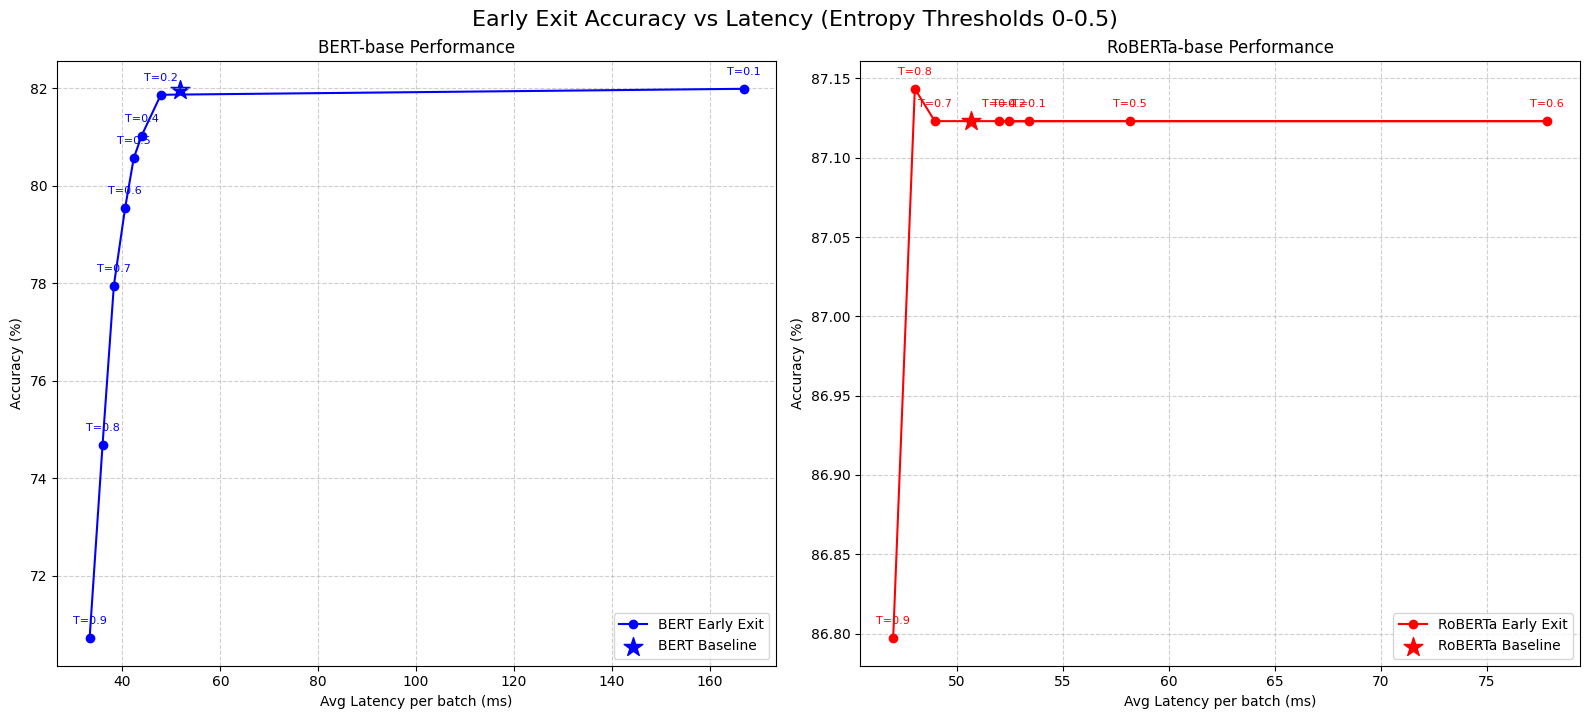

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# BERT Plot
ax1.plot(bert_ee_lats, bert_ee_accs, 'bo-', label='BERT Early Exit')
ax1.scatter([bert_base_lat], [bert_base_acc], color='blue', marker='*', s=200, label='BERT Baseline')
for i, t in enumerate(thresholds):
    ax1.annotate(f"T={t}", (bert_ee_lats[i], bert_ee_accs[i]), 
                 textcoords="offset points", xytext=(0, 10), ha='center', color='blue', fontsize=8)
ax1.set_title('BERT-base Performance')
ax1.set_xlabel('Avg Latency per batch (ms)')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# RoBERTa Plot
ax2.plot(roberta_ee_lats, roberta_ee_accs, 'ro-', label='RoBERTa Early Exit')
ax2.scatter([roberta_base_lat], [roberta_base_acc], color='red', marker='*', s=200, label='RoBERTa Baseline')
for i, t in enumerate(thresholds):
    ax2.annotate(f"T={t}", (roberta_ee_lats[i], roberta_ee_accs[i]), 
                 textcoords="offset points", xytext=(0, 10), ha='center', color='red', fontsize=8)
ax2.set_title('RoBERTa-base Performance')
ax2.set_xlabel('Avg Latency per batch (ms)')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.suptitle('Early Exit Accuracy vs Latency (Entropy Thresholds 0-0.5)', y=1.02, fontsize=16)
plt.show()